# Работа по теме "Временные ряды"

## Описание

Работа предполагает самостоятельное исследование данных и построение моделей прогнозирования временных рядов.

Основная задача работы - научиться работать с временными рядами, прогнозировать их.

Предлагается один набор данных.

Примерные критерии оценки:
- представленные данные изучены и описаны;
- данные предобработаны при необходимости, разделены на выборки;
- показано исследование данных на предмет автокорреляций, оптимальных лагов;
- рассмотрено не менее двух моделей прогнозирования;
- рассмотрены различные метрики для оценки, при описании результатов метрики верно интерпретированы.

В результате необходимо получить наилучшую модель прогнозирования временных рядов, при этом основную метрику разрешается выбрать самостоятельно, объяснив свой выбор. Также должен быть показан весь процесс исследования данных и настройки моделей.

## Импорт библиотек

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# !pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 35.8 MB/s eta 0:00:00


# Температурные изменения

Набор данных `MLTempDataset.csv` содержит показания комнатной температуры в зависимости от времени.

Требуется построить модель, позволяющую прогнозировать температуру.

In [4]:
df = pd.read_csv('MLTempDataset.csv')
df = df.drop('Unnamed: 0', axis = 1)
df.head()

,Datetime,Hourly_Temp
0,2022-01-04 00:00:00,20.867
1,2022-01-04 01:00:00,21.000
2,2022-01-04 02:00:00,20.867
3,2022-01-04 03:00:00,20.650
4,2022-01-04 04:00:00,20.400


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     7056 non-null   object 
 1   Hourly_Temp  7056 non-null   float64
dtypes: float64(1), object(1)
memory usage: 110.4+ KB


In [6]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     7056 non-null   datetime64[ns]
 1   Hourly_Temp  7056 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 110.4 KB


In [7]:
df.set_index('Datetime', inplace=True)
df.head()

,Hourly_Temp
Datetime,
2022-01-04 00:00:00,20.867
2022-01-04 01:00:00,21.000
2022-01-04 02:00:00,20.867
2022-01-04 03:00:00,20.650
2022-01-04 04:00:00,20.400


Text(0.5, 1.0, 'График температуры в комнате')

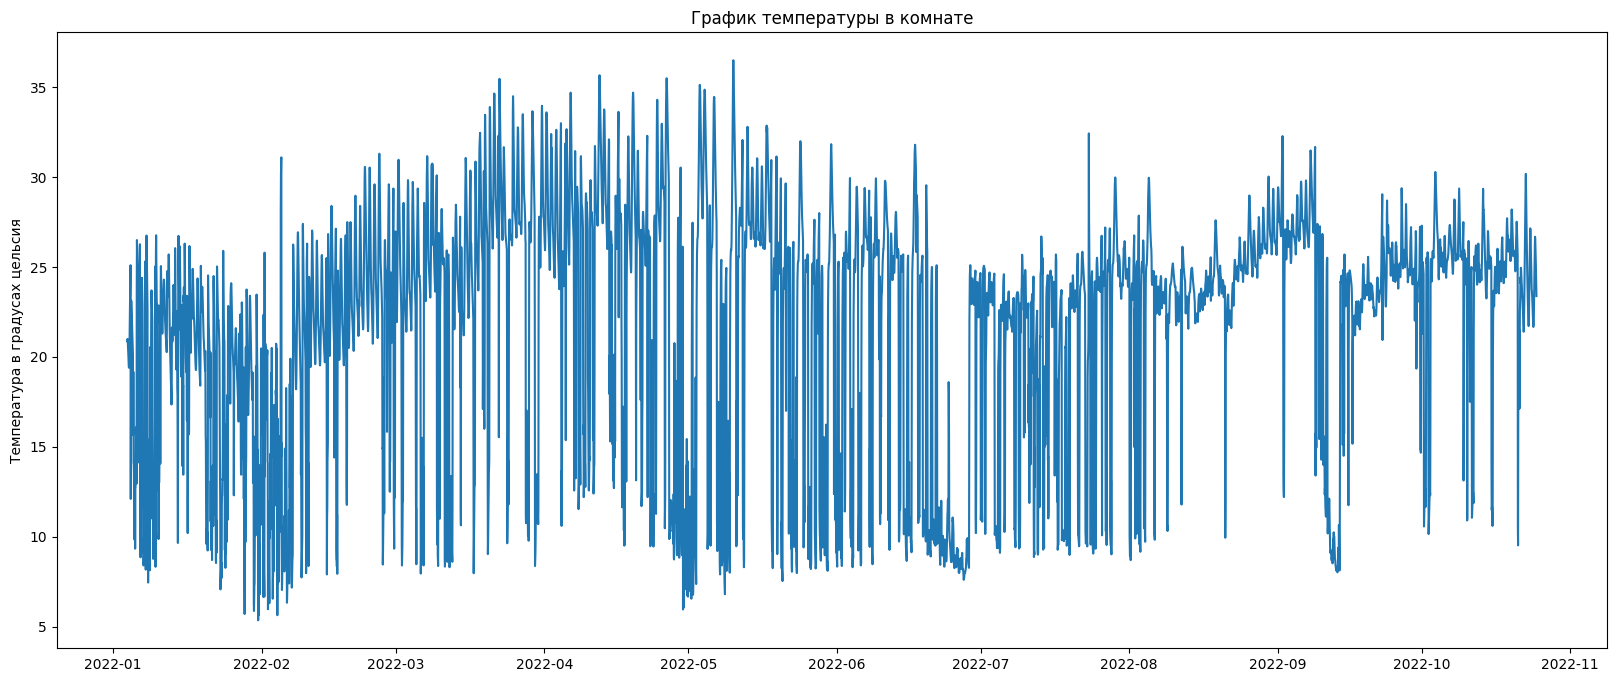

In [9]:
plt.figure(figsize=(20, 8))
plt.plot(df.index, df['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате")

/tmp/ipykernel_6357/3478113302.py:4: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_month = df.resample('1m').mean()


Text(0.5, 1.0, 'График температуры в комнате')

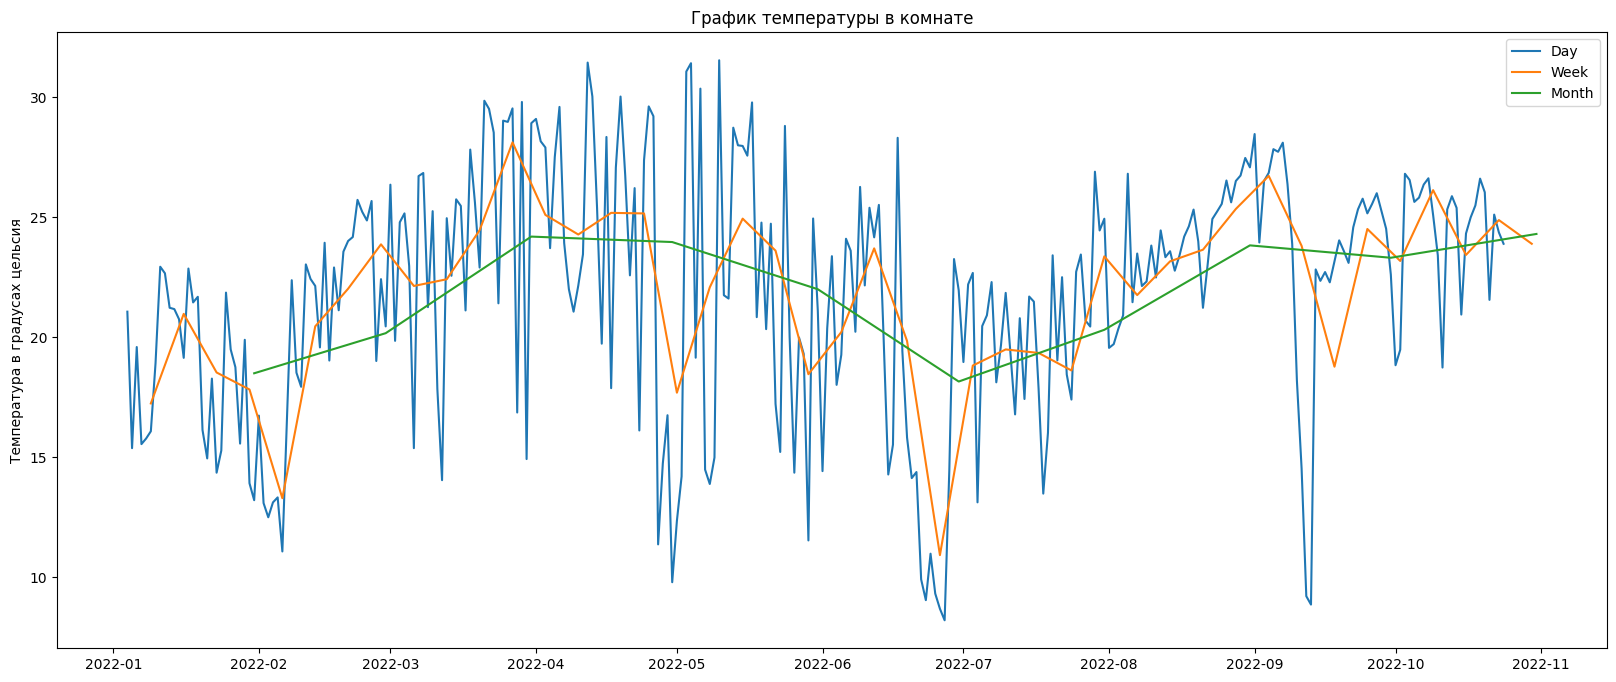

In [10]:
plt.figure(figsize=(20, 8))
df_days = df.resample('1D').mean()
df_week = df.resample('1W').mean()
df_month = df.resample('1m').mean()
plt.plot(df_days.index, df_days['Hourly_Temp'], label='Day')
plt.plot(df_week.index, df_week['Hourly_Temp'], label='Week')
plt.plot(df_month.index, df_month['Hourly_Temp'], label='Month')
plt.legend()
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате")

In [11]:
df_less_12 = df_days[df_days['Hourly_Temp'] <= 12]
df_less_12

,Hourly_Temp
Datetime,
2022-02-06,11.071250
2022-04-27,11.366042
2022-04-30,9.788833
2022-05-29,11.530917
2022-06-22,9.906250
2022-06-23,9.042292
2022-06-24,10.977792
2022-06-25,9.315375
2022-06-26,8.681833


In [12]:
df_days['Hourly_Temp'].sort_values(ascending=True).head(15)

,Hourly_Temp
Datetime,
2022-06-27,8.202833
2022-06-26,8.681833
2022-09-13,8.857000
2022-06-23,9.042292
2022-09-12,9.206667
2022-06-25,9.315375
2022-04-30,9.788833
2022-06-22,9.906250
2022-06-24,10.977792


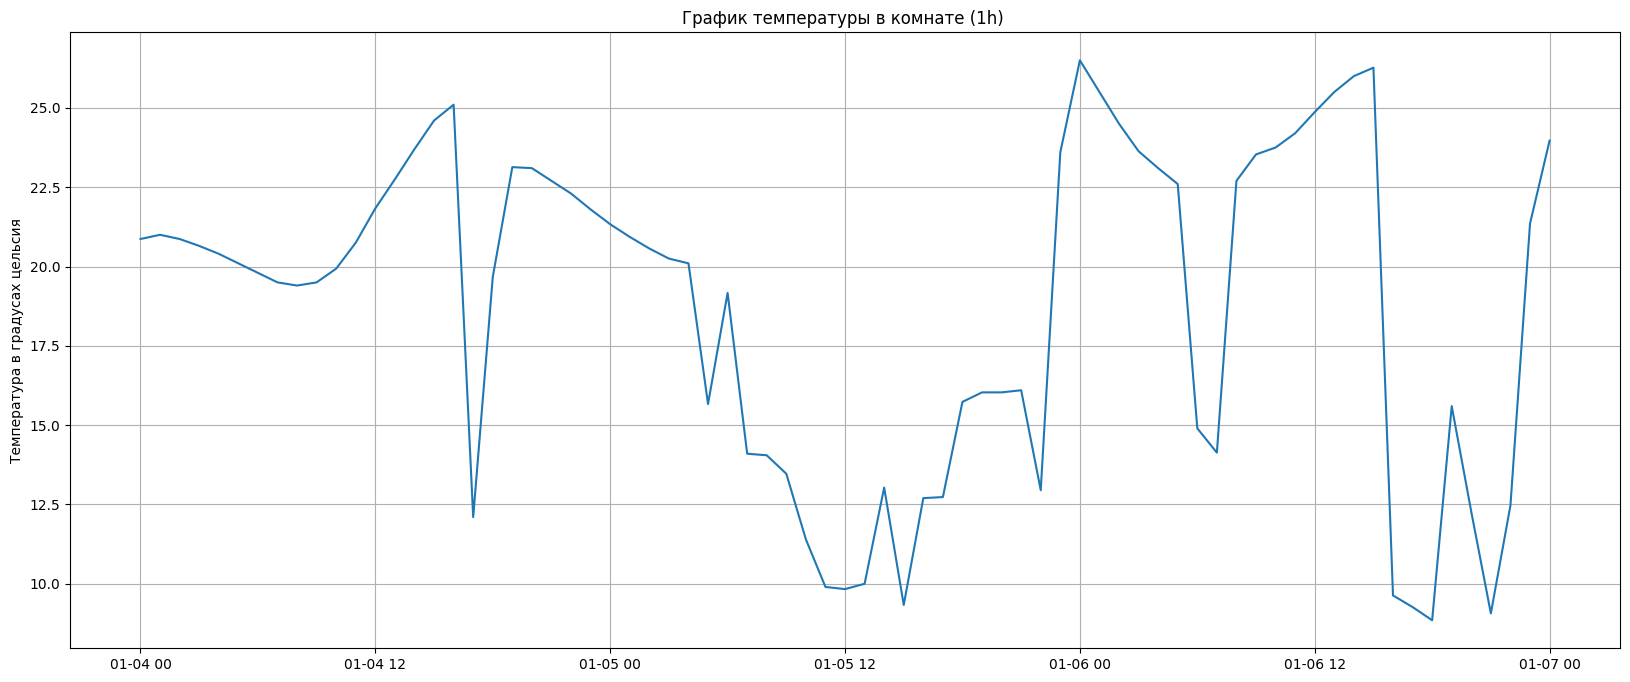

In [13]:
plt.figure(figsize=(20, 8))
dt = df.iloc[:73]
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (1h) ")
plt.grid()

Text(0.5, 1.0, 'График температуры в комнате (3h)')

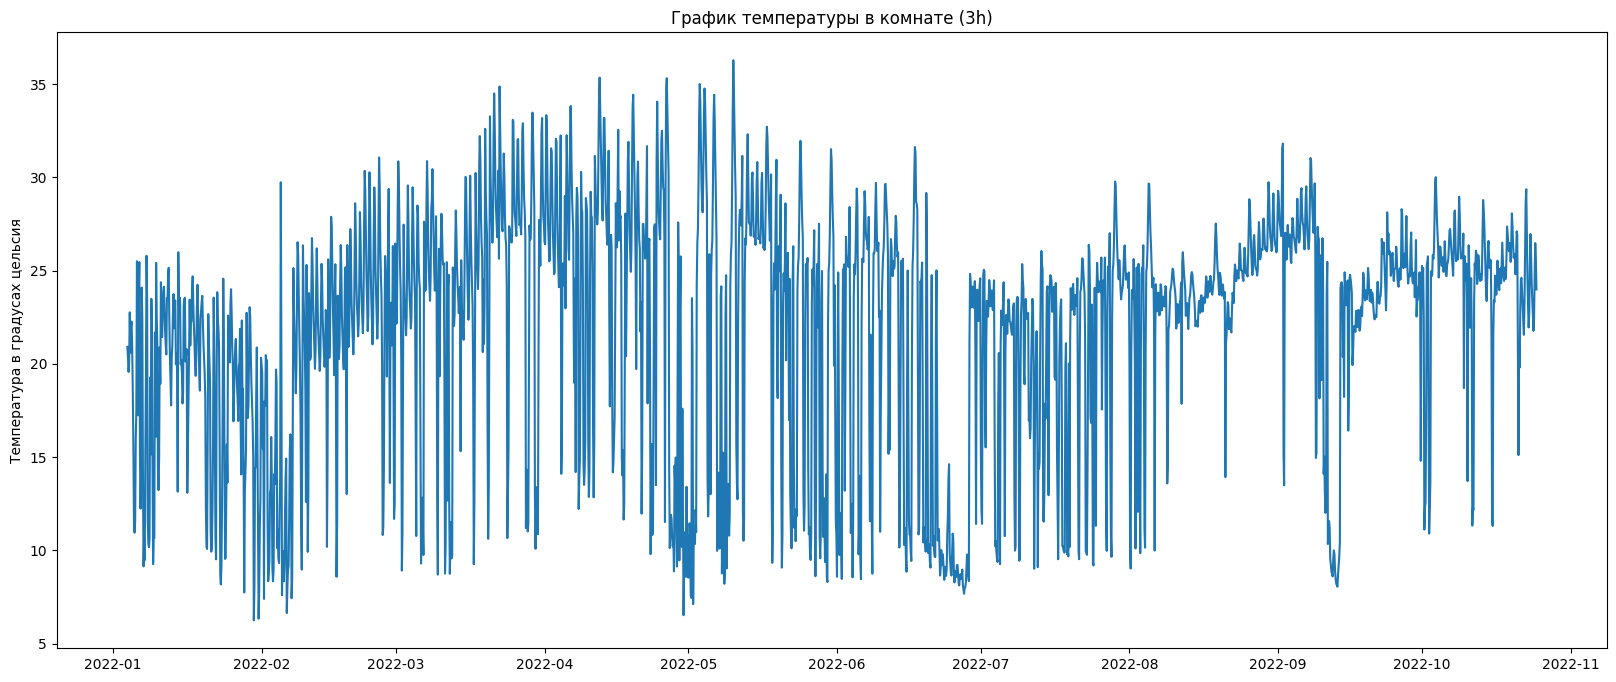

In [14]:
plt.figure(figsize=(20, 8))
dt = df.resample('3h').mean()
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h)")

Text(0.5, 1.0, 'График температуры в комнате (3h) ')

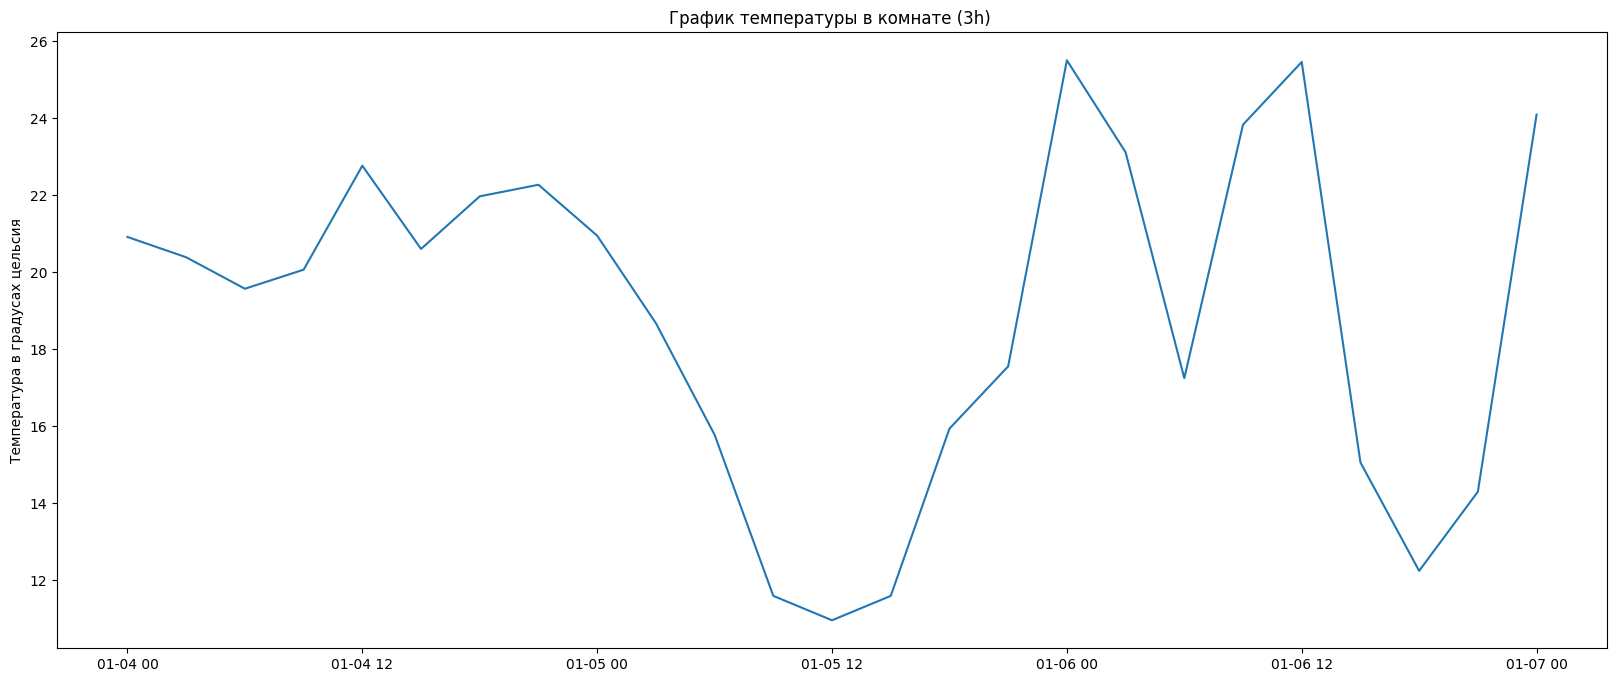

In [15]:
plt.figure(figsize=(20, 8))
dt = dt.iloc[:25]
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h) ")

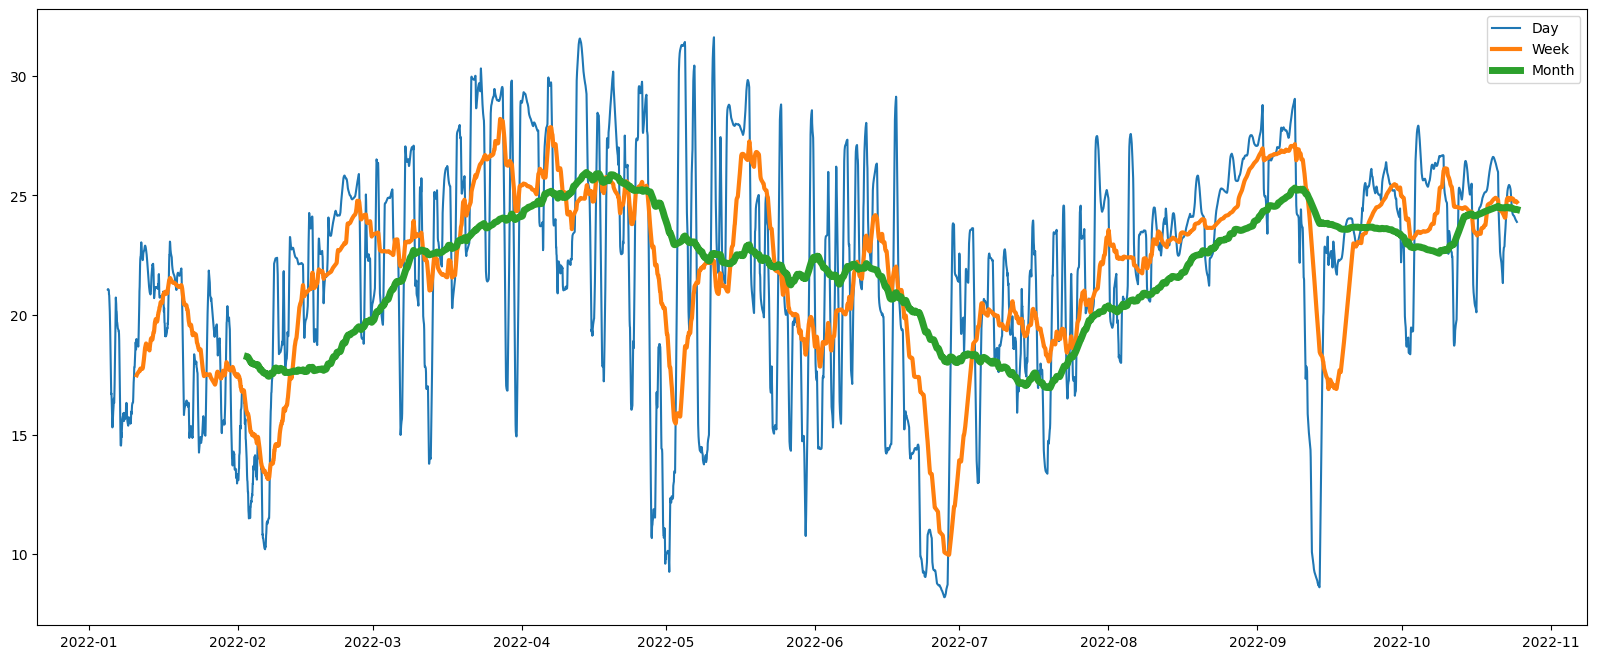

In [16]:
plt.figure(figsize=(20, 8))
df_roll_days = df.rolling(window=24).mean()
df_roll_week = df.rolling(window=168).mean()
df_roll_month = df.rolling(window=720).mean()
plt.plot(df_roll_days.index, df_roll_days['Hourly_Temp'], label='Day')
plt.plot(df_roll_week.index, df_roll_week['Hourly_Temp'], label='Week', lw=3)
plt.plot(df_roll_month.index, df_roll_month['Hourly_Temp'], label='Month', linewidth=5)
plt.legend()

Text(0.5, 1.0, 'График температуры в комнате (3h)')

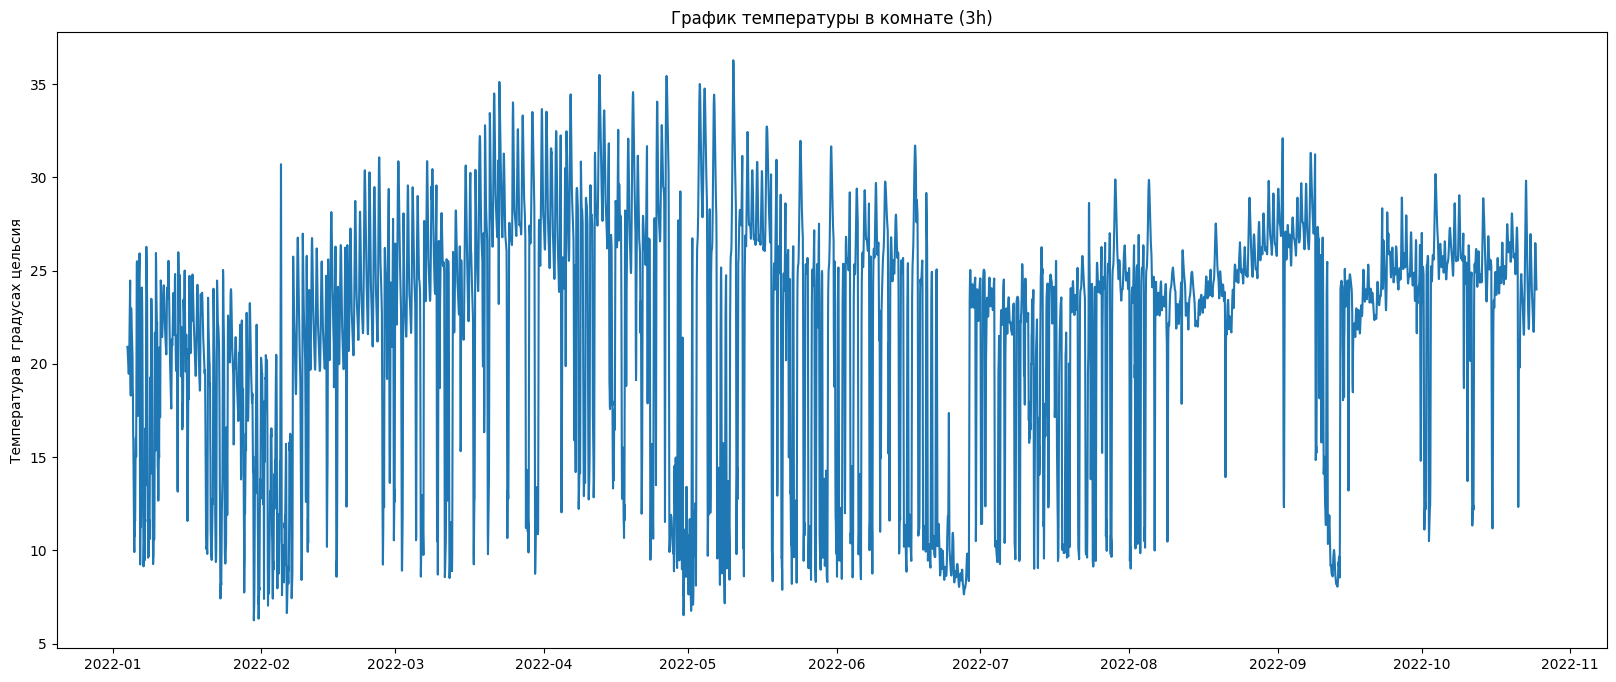

In [17]:
plt.figure(figsize=(20, 8))
dt = df.rolling(window=3).mean()
plt.plot(dt.index, dt['Hourly_Temp'])
plt.ylabel("Температура в градусах цельсия")
plt.title("График температуры в комнате (3h)")

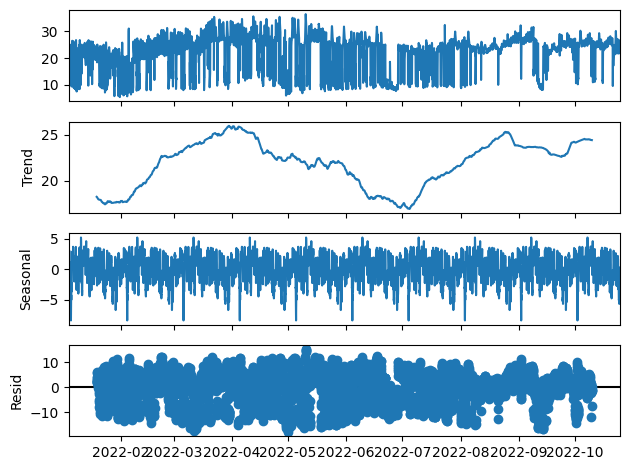

In [18]:
seasonal_decompose(df, model = 'additive', period = 720).plot()
plt.show()

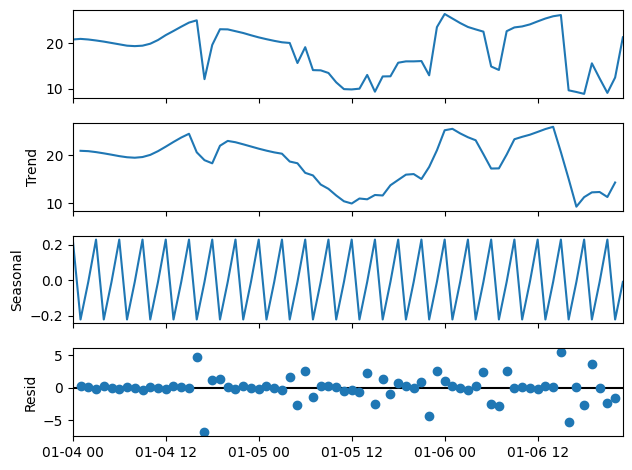

In [19]:
seasonal_decompose(df.head(72), model = 'additive', period = 3).plot()
plt.show()

<Axes: >

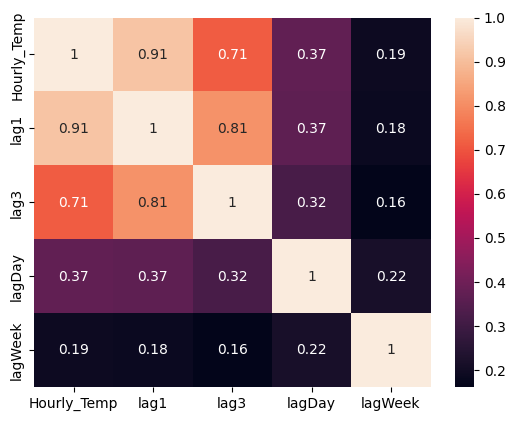

In [20]:
df['lag1'] = df['Hourly_Temp'].shift(1, axis = 0)
df['lag3'] = df['Hourly_Temp'].shift(3, axis = 0)
df['lagDay'] = df['Hourly_Temp'].shift(24, axis = 0)
df['lagWeek'] = df['Hourly_Temp'].shift(168, axis = 0)


sns.heatmap(df.corr(), annot = True)

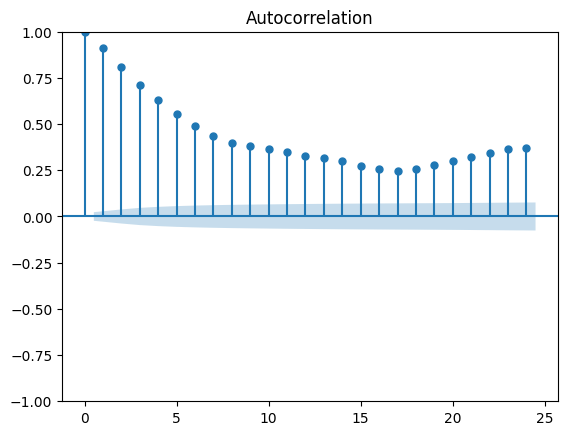

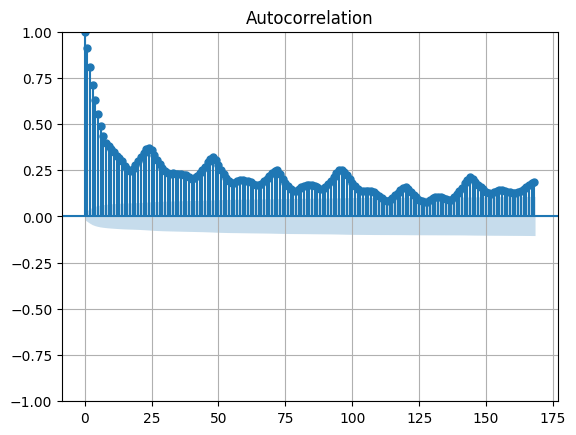

In [21]:
plot_acf(df['Hourly_Temp'], lags = 24)
plot_acf(df['Hourly_Temp'], lags = 168)
plt.grid(True)
plt.show()

In [22]:
def metrics(true, pred):
    print('R2:', r2_score(true, pred))
    print('MAE:', mean_absolute_error(true, pred))
    print('RMSE:', mean_squared_error(true, pred)**0.5)

In [23]:
df.index.freq = 'h'
steps = round(df.shape[0] * 0.2)
df_train = df[:-steps]
df_test  = df[-steps:]
print(df_train.shape, df_test.shape)

(5645, 5) (1411, 5)


In [25]:
forecaster = ForecasterRecursive(
    estimator = LinearRegression(),
    lags = 1)

forecaster.fit(df_train['Hourly_Temp'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LinearRegression 
Lags: [1] 
Window features: None 
Window size: 1 
Series name: Hourly_Temp 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2022-01-04 00:00:00'), Timestamp('2022-08-27 04:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False} 
fit_kwargs: {} 
Creation date: 2026-06-20 17:16:22 
Last fit date: 2026-06-20 17:16:22 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [26]:
steps = len(df_test)

y_pred = forecaster.predict(steps = steps)
y_pred.head()

,pred
2022-08-27 05:00:00,25.716070
2022-08-27 06:00:00,25.321337
2022-08-27 07:00:00,24.962260
2022-08-27 08:00:00,24.635618
2022-08-27 09:00:00,24.338481


In [27]:
metrics(df_test['Hourly_Temp'], y_pred)

R2: -0.3014238162522058
MAE: 4.740631691669363
RMSE: 5.414404910795272


# Выводы

Ключевые выводы по задачам.

### Этапы работы:
1.  Загрузка и предобработка данных: Данные были загружены, столбец 'Unnamed: 0' удален. Столбец 'Datetime' был преобразован в формат `datetime` и установлен в качестве индекса DataFrame. Частота индекса установлена как 'h' (часовая).
2.  Визуализация и агрегация: Исходный временной ряд был визуализирован. Для лучшего понимания сезонности и трендов были построены графики среднегодовой, среднедневной и среднемесячной температуры.
3.  Анализ аномалий: Были выявлены дни со средней температурой ниже 12 градусов Цельсия, что может указывать на аномально низкие значения или особенности данных.
4.  Анализ сезонности и трендов: Использовались скользящие средние (дневное, недельное, месячное) для сглаживания данных и выявления основных тенденций. Декомпозиция временного ряда с аддитивной моделью показала наличие сезонности (период 720 часов, т.е. 30 дней) и, возможно, недельной сезонности (период 3 часа для короткого промежутка).
5.  Автокорреляционный анализ: Были рассчитаны лаги (1 час, 3 часа, 24 часа, 168 часов) и построена тепловая карта корреляций. Графики автокорреляционной функции (ACF) для 24 и 168 лагов подтвердили сильную суточную и недельную сезонность.
6.  Моделирование: Временной ряд был разделен на обучающую (80%) и тестовую (20%) выборки. Использовалась модель `ForecasterRecursive` с `LinearRegression` в качестве эстиматора и одним лагом.

### Результаты прогнозирования:
*   **R2**: -0.3014 - очень низкое значение, указывающее на то, что модель объясняет менее 0% дисперсии тестовых данных, что является плохим результатом. Это говорит о том, что модель работает хуже, чем простое предсказание среднего значения.
*   **MAE**: 4.7406 - средняя абсолютная ошибка составляет примерно 4.74 градуса Цельсия.
*   **RMSE**: 5.4144 - среднеквадратическая ошибка составляет примерно 5.41 градуса Цельсия.